In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import joblib

# ==========================================================
# 1. Load Data
# ==========================================================
print("Step 1: Loading dataset and filtering missing targets...")

df = pd.read_csv("DrugDelivery_Silver.csv")

df = df.dropna(subset=[
    "Tumor_%ID",
    "Selectivity_Index",
    "NPs ID"
])

# ==========================================================
# 2. Convert Regression Targets to Classification Targets
# ==========================================================
df["Tumor_Class"] = (
    df["Tumor_%ID"] >= df["Tumor_%ID"].median()
).astype(int)

df["Selectivity_Class"] = (
    df["Selectivity_Index"] >= df["Selectivity_Index"].median()
).astype(int)

# ==========================================================
# 3. Features & Targets
# ==========================================================
features = [
    "NP_Class",
    "INPs_Core",
    "Shape",
    "Size (nm)",
    "Size_Category",
    "Zeta Potential (mv)",
    "Zeta_Category",
    "Organ or tissue",
    "HAS_PEG",
    "Shell Type",
    "Administration Dosages (mg/kg)",
    "Time point (h)",
    "Tumor Site"
]

targets = [
    "Tumor_Class",
    "Selectivity_Class"
]

X = df[features].copy()
y = df[targets]
groups = df["NPs ID"]

# ==========================================================
# 4. Manual Encoding
# ==========================================================
categorical_features = [
    "NP_Class",
    "INPs_Core",
    "Shape",
    "Size_Category",
    "Zeta_Category",
    "Organ or tissue",
    "HAS_PEG",
    "Shell Type",
    "Tumor Site"
]

encoding_maps = {}
X_encoded = X.copy()

for col in categorical_features:

    X_encoded[col] = (
        X_encoded[col]
        .astype(str)
        .str.strip()
    )

    unique_vals = X_encoded[col].unique()

    mapping = {
        value: float(i)
        for i, value in enumerate(unique_vals)
    }

    encoding_maps[col] = mapping

    X_encoded[col] = X_encoded[col].map(mapping)

# ==========================================================
# 5. Numeric Columns
# ==========================================================
numeric_features = [
    "Size (nm)",
    "Zeta Potential (mv)",
    "Administration Dosages (mg/kg)",
    "Time point (h)"
]

for col in numeric_features:
    X_encoded[col] = pd.to_numeric(
        X_encoded[col],
        errors="coerce"
    )

# ==========================================================
# 6. Build XGBoost Classifier
# ==========================================================
model = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        random_state=42,
        n_jobs=-1
    )
)

# ==========================================================
# 7. GroupKFold Cross Validation
# ==========================================================
gkf = GroupKFold(n_splits=5)

metrics = {
    target: {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": []
    }
    for target in targets
}

print("\nExecuting GroupKFold Cross Validation...\n")

fold = 1

for train_idx, test_idx in gkf.split(
    X_encoded,
    y,
    groups=groups
):

    print(f"Fold {fold}")

    X_train = X_encoded.iloc[train_idx]
    X_test = X_encoded.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    for i, target in enumerate(targets):

        y_true = y_test.iloc[:, i]
        y_pred = predictions[:, i]

        acc = accuracy_score(y_true, y_pred)
        pre = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        metrics[target]["accuracy"].append(acc)
        metrics[target]["precision"].append(pre)
        metrics[target]["recall"].append(rec)
        metrics[target]["f1"].append(f1)

        print(f"{target}")
        print(f" Accuracy : {acc:.4f}")
        print(f" Precision: {pre:.4f}")
        print(f" Recall   : {rec:.4f}")
        print(f" F1 Score : {f1:.4f}")
        print()

    fold += 1

# ==========================================================
# 8. Final Results
# ==========================================================
print("\n================ FINAL RESULTS ================\n")

for target in targets:

    print(f"Target: {target}")

    print(f"Average Accuracy : {np.mean(metrics[target]['accuracy']):.4f}")
    print(f"Average Precision: {np.mean(metrics[target]['precision']):.4f}")
    print(f"Average Recall   : {np.mean(metrics[target]['recall']):.4f}")
    print(f"Average F1 Score : {np.mean(metrics[target]['f1']):.4f}")

    print("-" * 50)

# ==========================================================
# 9. Train Final Model
# ==========================================================
print("\nTraining final model...")

model.fit(X_encoded, y)

joblib.dump(
    model,
    "xgboost_nano_classifier_model.pkl"
)

joblib.dump(
    encoding_maps,
    "nano_preprocessor.pkl"
)

print("\nModel Saved Successfully!")

Step 1: Loading dataset and filtering missing targets...

Executing GroupKFold Cross Validation...

Fold 1
Tumor_Class
 Accuracy : 0.6870
 Precision: 0.6119
 Recall   : 0.6340
 F1 Score : 0.6228

Selectivity_Class
 Accuracy : 0.4622
 Precision: 0.2619
 Recall   : 0.3526
 F1 Score : 0.3005

Fold 2
Tumor_Class
 Accuracy : 0.6758
 Precision: 0.6477
 Recall   : 0.5534
 F1 Score : 0.5969

Selectivity_Class
 Accuracy : 0.5811
 Precision: 0.7943
 Recall   : 0.3972
 F1 Score : 0.5296

Fold 3
Tumor_Class
 Accuracy : 0.5264
 Precision: 0.5645
 Recall   : 0.5469
 F1 Score : 0.5556

Selectivity_Class
 Accuracy : 0.5751
 Precision: 0.5200
 Recall   : 0.4976
 F1 Score : 0.5086

Fold 4
Tumor_Class
 Accuracy : 0.5389
 Precision: 0.6057
 Recall   : 0.6713
 F1 Score : 0.6368

Selectivity_Class
 Accuracy : 0.6274
 Precision: 0.6187
 Recall   : 0.8722
 F1 Score : 0.7239

Fold 5
Tumor_Class
 Accuracy : 0.6779
 Precision: 0.7559
 Recall   : 0.6145
 F1 Score : 0.6779

Selectivity_Class
 Accuracy : 0.7242
 Pr


Generating Chart 1: Fixed Correlation Matrix Heatmap...


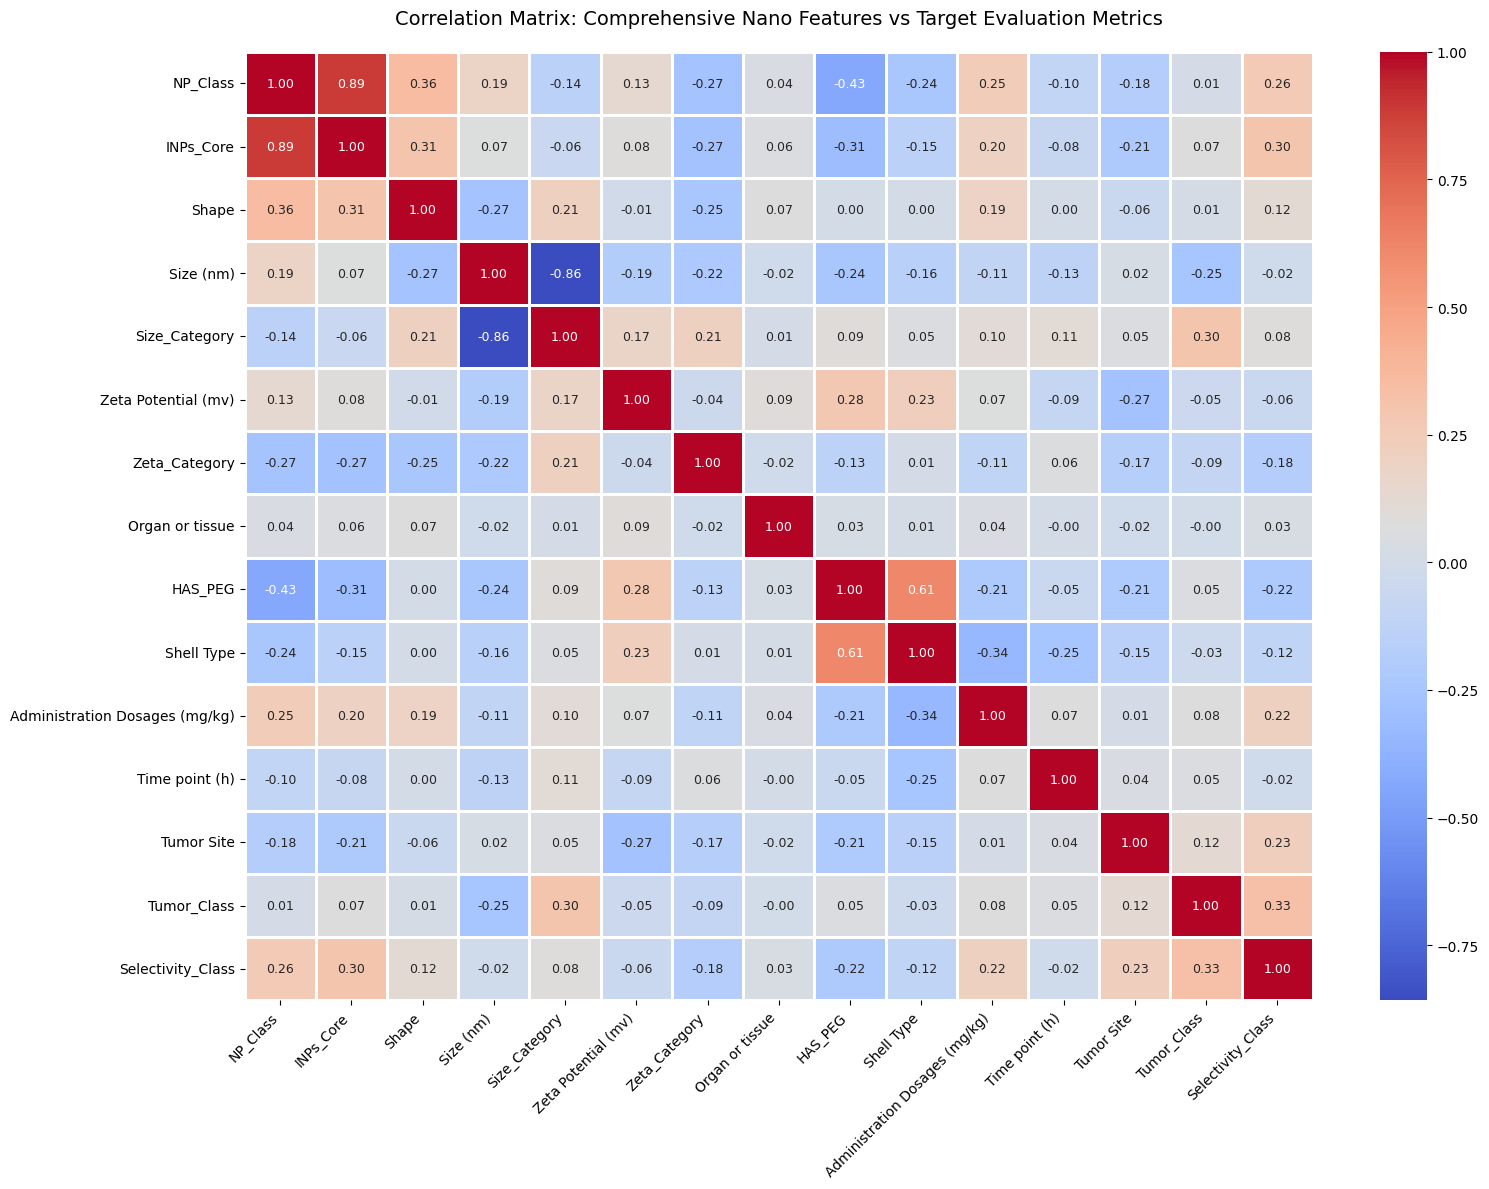

-> Complete Correlation Matrix generated successfully with no missing tracking blocks!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("\nGenerating Chart 1: Fixed Correlation Matrix Heatmap...")

# Step 1: Define your 13 features and 2 targets
final_features = [
    "NP_Class", "INPs_Core", "Shape", "Size (nm)", "Size_Category",
    "Zeta Potential (mv)", "Zeta_Category", "Organ or tissue", "HAS_PEG",
    "Shell Type", "Administration Dosages (mg/kg)", "Time point (h)", "Tumor Site"
]
targets = ['Tumor_Class', 'Selectivity_Class']

# Step 2: Initialize clean DataFrame for correlation
df_analysis = pd.DataFrame()

# Copy continuous numerical attributes and force float type safely
num_cols = ['Size (nm)', 'Zeta Potential (mv)', 'Administration Dosages (mg/kg)', 'Time point (h)']
for col in num_cols:
    if col in X.columns:
        df_analysis[col] = pd.to_numeric(X[col], errors='coerce').astype(float)

# Step 3: Use Dynamic LabelEncoder for all categorical columns to prevent NaN/White blocks
le = LabelEncoder()

cat_cols = ["NP_Class", "INPs_Core", "Shape", "Size_Category", "Zeta_Category", "Organ or tissue", "HAS_PEG", "Shell Type", "Tumor Site"]
for col in cat_cols:
    if col in X.columns:
        # Fill missing text rows with 'Unknown' dynamically to avoid encoding crashes
        filled_series = X[col].fillna('Unknown').astype(str)
        df_analysis[col] = le.fit_transform(filled_series)

# Step 4: Encode the targets dynamically as well
if isinstance(y, pd.DataFrame):
    df_analysis['Tumor_Class'] = le.fit_transform(y['Tumor_Class'].fillna('Low').astype(str))
    df_analysis['Selectivity_Class'] = le.fit_transform(y['Selectivity_Class'].fillna('Low').astype(str))
else:
    # If y is a dictionary or custom tracking structure
    df_analysis['Tumor_Class'] = le.fit_transform(pd.Series(y['Tumor_Class']).fillna('Low').astype(str))
    df_analysis['Selectivity_Class'] = le.fit_transform(pd.Series(y['Selectivity_Class']).fillna('Low').astype(str))

# Step 5: Enforce strict column structural layout order
ordered_columns = final_features + targets
df_analysis = df_analysis.reindex(columns=ordered_columns)

# Step 6: Generate and plot the clean complete correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df_analysis.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.8,
    annot_kws={"size": 9},
    mask=correlation_matrix.isnull() # Smoothly handles display fallback if a feature is perfectly constant
)

plt.title('Correlation Matrix: Comprehensive Nano Features vs Target Evaluation Metrics', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

print("-> Complete Correlation Matrix generated successfully with no missing tracking blocks!")


Generating Chart 2: Feature Importance for Tumor_Class...


/tmp/ipykernel_19384/989634765.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


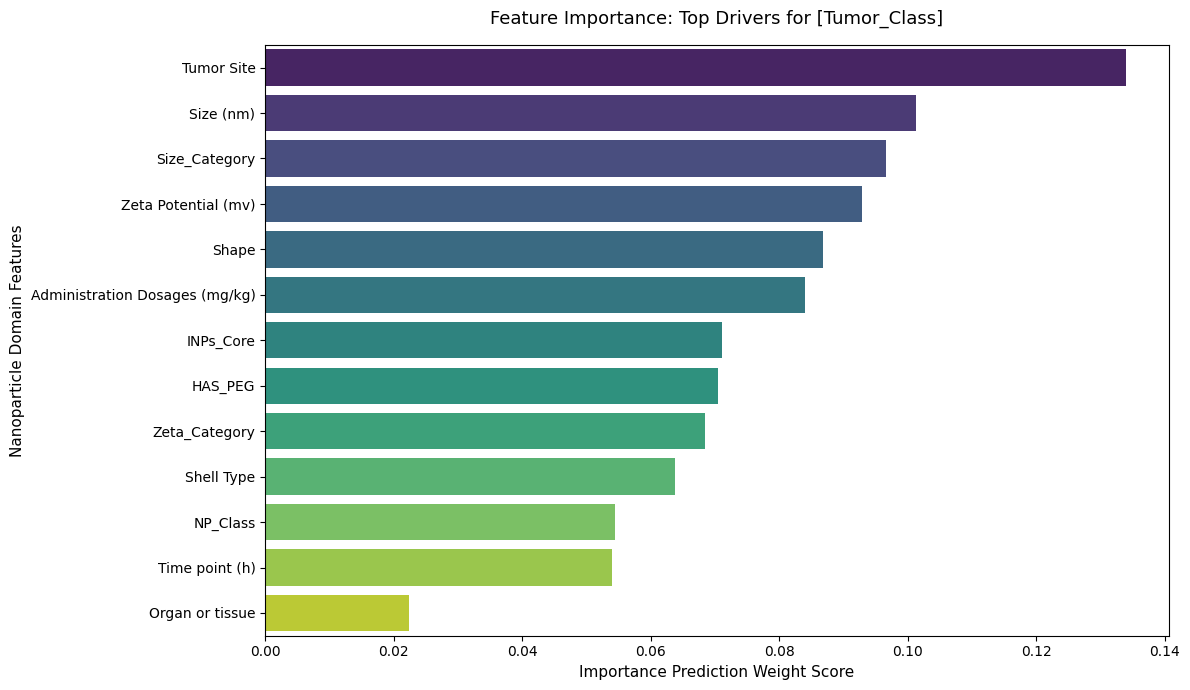

-> Tumor_Class Feature Importance generated and saved successfully!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating Chart 2: Feature Importance for Tumor_Class...")

final_features = [
    "NP_Class", "INPs_Core", "Shape", "Size (nm)", "Size_Category",
    "Zeta Potential (mv)", "Zeta_Category", "Organ or tissue", "HAS_PEG",
    "Shell Type", "Administration Dosages (mg/kg)", "Time point (h)", "Tumor Site"
]

# Extract the correct model component from the MultiOutputClassifier structure
current_model = tumor_model if 'tumor_model' in locals() else model

if hasattr(current_model, 'estimators_'):
    # Index 0 contains the trained XGBoost tree for the first target (Tumor_Class)
    importances = current_model.estimators_[0].feature_importances_
elif hasattr(current_model, 'feature_importances_'):
    importances = current_model.feature_importances_
else:
    importances = current_model.named_steps['regressor'].estimators_[0].feature_importances_

# Sort features by predictive weight
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 7))
sns.barplot(
    x=[importances[idx] for idx in indices],
    y=[final_features[idx] for idx in indices],
    palette='viridis'
)

plt.title('Feature Importance: Top Drivers for [Tumor_Class]', fontsize=13, pad=15)
plt.xlabel('Importance Prediction Weight Score', fontsize=11)
plt.ylabel('Nanoparticle Domain Features', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance_Tumor_Class.png', dpi=300)
plt.show()

print("-> Tumor_Class Feature Importance generated and saved successfully!")


Generating Chart 3: Feature Importance for Selectivity_Class...


/tmp/ipykernel_19384/1016717660.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


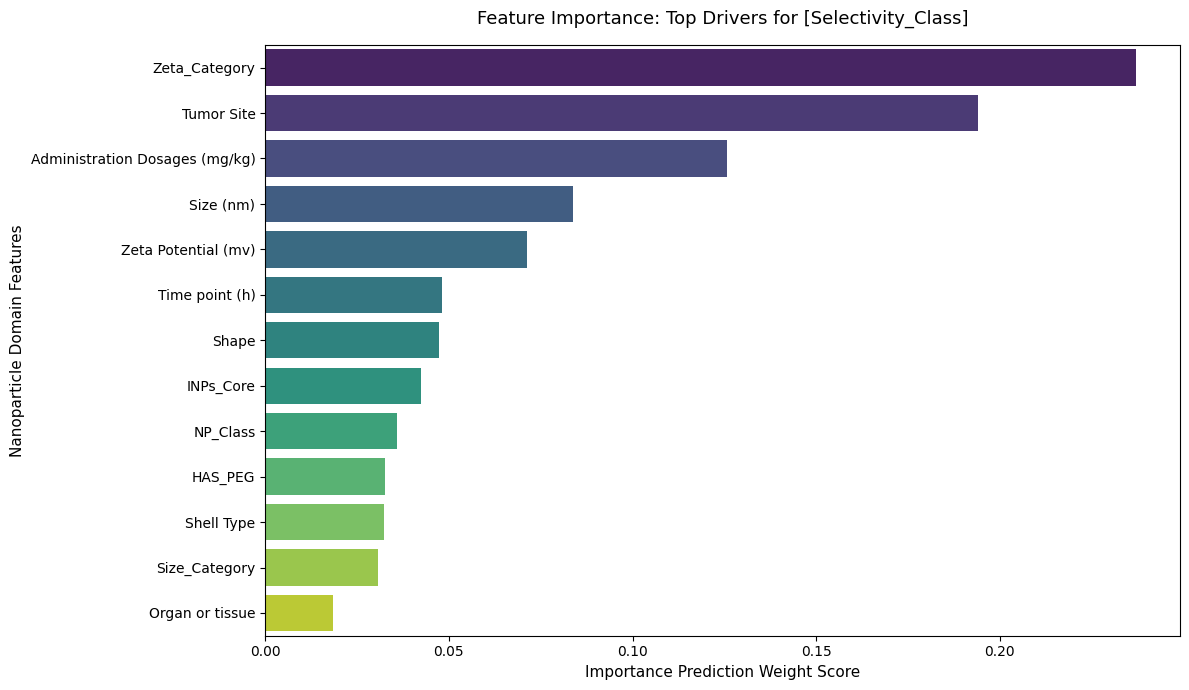

-> Selectivity_Class Feature Importance generated and saved successfully!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating Chart 3: Feature Importance for Selectivity_Class...")

final_features = [
    "NP_Class", "INPs_Core", "Shape", "Size (nm)", "Size_Category",
    "Zeta Potential (mv)", "Zeta_Category", "Organ or tissue", "HAS_PEG",
    "Shell Type", "Administration Dosages (mg/kg)", "Time point (h)", "Tumor Site"
]

# Extract the correct model component from the MultiOutputClassifier structure
current_model = selectivity_model if 'selectivity_model' in locals() else model

if hasattr(current_model, 'estimators_'):
    # Index 1 contains the trained XGBoost tree for the second target (Selectivity_Class)
    importances = current_model.estimators_[1].feature_importances_
elif hasattr(current_model, 'feature_importances_'):
    importances = current_model.feature_importances_
else:
    importances = current_model.named_steps['regressor'].estimators_[1].feature_importances_

# Sort features by predictive weight
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 7))
sns.barplot(
    x=[importances[idx] for idx in indices],
    y=[final_features[idx] for idx in indices],
    palette='viridis'
)

plt.title('Feature Importance: Top Drivers for [Selectivity_Class]', fontsize=13, pad=15)
plt.xlabel('Importance Prediction Weight Score', fontsize=11)
plt.ylabel('Nanoparticle Domain Features', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance_Selectivity_Class.png', dpi=300)
plt.show()

print("-> Selectivity_Class Feature Importance generated and saved successfully!")